请在弹出的窗口中上传你的 data.csv 文件...


Saving data.csv to data.csv
数据读取成功！

数据行数、列数: (149, 20)
前5行数据:
   Country name Regional indicator  Ladder score  \
0      Finland     Western Europe         7.842   
1      Denmark     Western Europe         7.620   
2  Switzerland     Western Europe         7.571   
3      Iceland     Western Europe         7.554   
4  Netherlands     Western Europe         7.464   

   Standard error of ladder score  upperwhisker  lowerwhisker  \
0                           0.032         7.904         7.780   
1                           0.035         7.687         7.552   
2                           0.036         7.643         7.500   
3                           0.059         7.670         7.438   
4                           0.027         7.518         7.410   

   Logged GDP per capita  Social support  Healthy life expectancy  \
0                 10.775           0.954                     72.0   
1                 10.933           0.954                     72.7   
2                 11.117       

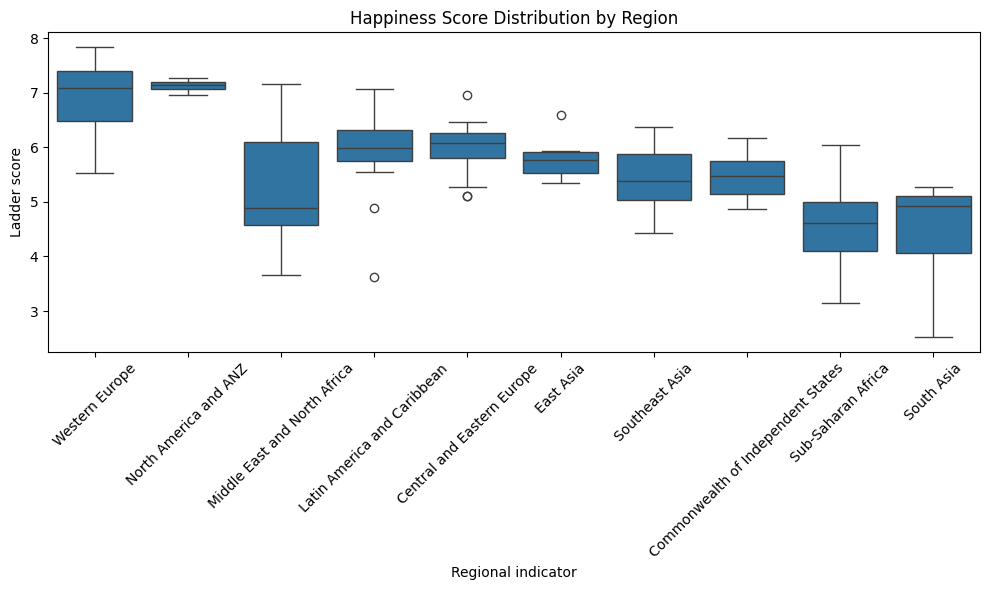

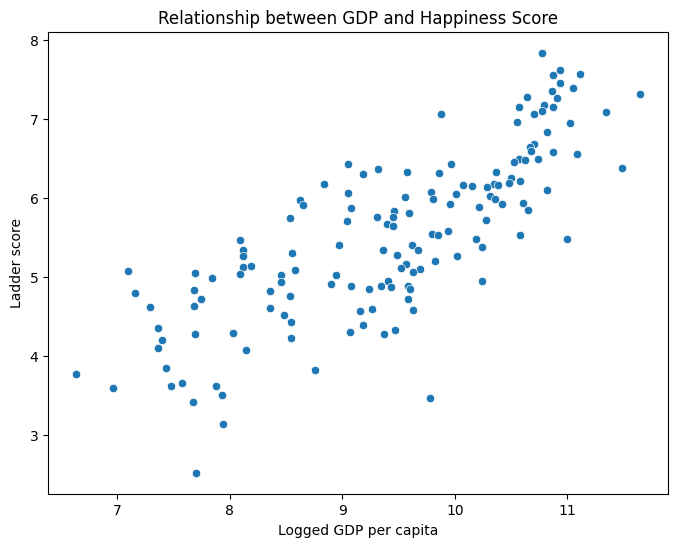

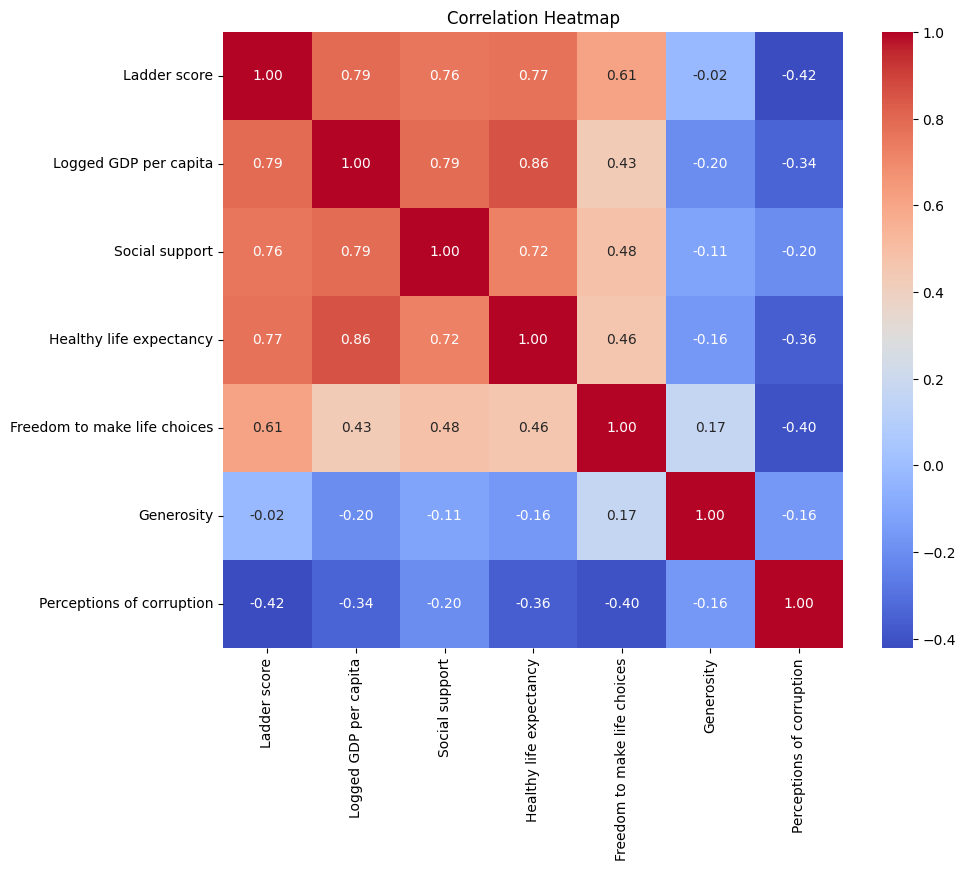

                            OLS Regression Results                            
Dep. Variable:           Ladder score   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     109.0
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           5.51e-37
Time:                        09:04:48   Log-Likelihood:                -133.61
No. Observations:                 149   AIC:                             275.2
Df Residuals:                     145   BIC:                             287.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [13]:
# 1. 导入库
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from google.colab import files
import io

# 2. 上传并读取数据（运行这一段后，点击弹出的按钮选择你下载的 data.csv 文件）
print("请在弹出的窗口中上传你的 data.csv 文件...")
uploaded = files.upload()

# 读取刚刚上传的文件
df = pd.read_csv(io.BytesIO(uploaded['data.csv']))
print("数据读取成功！")

# 3. 数据基本信息
print("\n数据行数、列数:", df.shape)
print("前5行数据:\n", df.head())
print("各列的数据类型和缺失值:\n", df.info())

# 4. 数据清洗：看看有没有缺失值，如果有就删除（这个数据集通常很干净）
df = df.dropna()
print("清洗后的行数:", df.shape)

# 5. 描述性统计
print("描述性统计:\n", df.describe())

# 6. 可视化 1：不同地区的幸福指数（箱线图）
# 看看哪个地区的幸福感分布最高
plt.figure(figsize=(10, 6))
sns.boxplot(x='Regional indicator', y='Ladder score', data=df)
plt.xticks(rotation=45)
plt.title('Happiness Score Distribution by Region')
plt.tight_layout()
plt.show()

# 7. 可视化 2：GDP和幸福指数的关系（散点图）
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Logged GDP per capita', y='Ladder score', data=df)
plt.title('Relationship between GDP and Happiness Score')
plt.show()

# 8. 可视化 3：相关热力图（看哪些因素和幸福感最相关）
# 选我们关注的数值列
numeric_cols = ['Ladder score', 'Logged GDP per capita', 'Social support',
                'Healthy life expectancy', 'Freedom to make life choices',
                'Generosity', 'Perceptions of corruption']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 9. 线性回归：用 GDP 和 社会支持 预测 幸福指数
X = df[['Logged GDP per capita', 'Social support', 'Healthy life expectancy']]
y = df['Ladder score']
X = sm.add_constant(X) # 添加截距项
model = sm.OLS(y, X).fit()
print(model.summary())